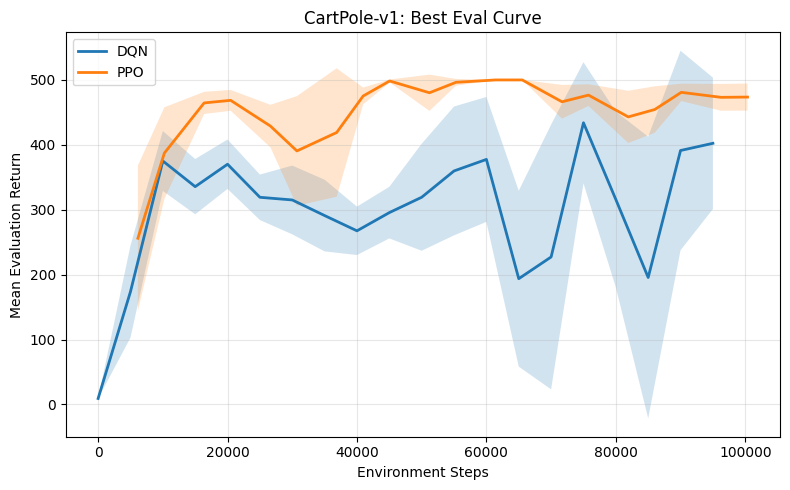

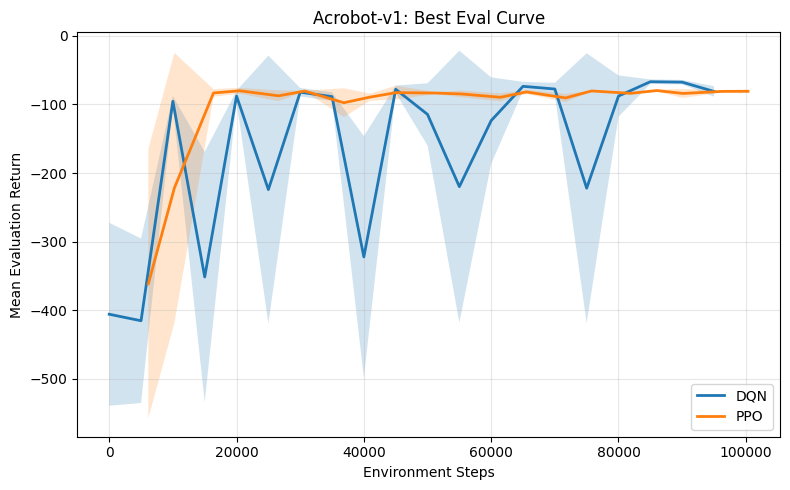

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = "rl results"

PLOTS = {
    "CartPole-v1": {
        "dqn": os.path.join(BASE_DIR, "DQN", "CartPole-v1", "best_eval_curve.csv"),
        "ppo": os.path.join(BASE_DIR, "PPO", "results", "Cartpole", "final_eval_curve.csv"),
        "output": "cartpole_dqn_vs_ppo.png",
    },
    "Acrobot-v1": {
        "dqn": os.path.join(BASE_DIR, "DQN", "Acrobot-v1", "best_eval_curve.csv"),
        "ppo": os.path.join(BASE_DIR, "PPO", "results", "Acrobat", "final_eval_curve.csv"),
        "output": "acrobot_dqn_vs_ppo.png",
    },
}


def plot_eval_curve(env_name, dqn_path, ppo_path, output_path):
    dqn = pd.read_csv(dqn_path)
    ppo = pd.read_csv(ppo_path)

    plt.figure(figsize=(8, 5))

    # DQN mean curve
    plt.plot(
        dqn["step"],
        dqn["mean_return"],
        label="DQN",
        linewidth=2,
    )
    plt.fill_between(
        dqn["step"],
        dqn["mean_return"] - dqn["std_return"],
        dqn["mean_return"] + dqn["std_return"],
        alpha=0.2,
    )

    # PPO mean curve
    plt.plot(
        ppo["step"],
        ppo["mean_return"],
        label="PPO",
        linewidth=2,
    )
    plt.fill_between(
        ppo["step"],
        ppo["mean_return"] - ppo["std_return"],
        ppo["mean_return"] + ppo["std_return"],
        alpha=0.2,
    )

    plt.title(f"{env_name}: Best Eval Curve")
    plt.xlabel("Environment Steps")
    plt.ylabel("Mean Evaluation Return")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(output_path, dpi=300)
    plt.show()


for env_name, cfg in PLOTS.items():
    plot_eval_curve(
        env_name=env_name,
        dqn_path=cfg["dqn"],
        ppo_path=cfg["ppo"],
        output_path=cfg["output"],
    )